# Removal of Signal Mergers from data

We want to remove the signal peak from the data, but we dont have acess to the full simulation suite that was used to produce Sangria-HM.
We therefore use the FastTDI waveform generator to make the signals and subtract (this is what was used for Sangria-HM), and any differences should be minimised.

Realistically, we will have run parameter estimation and got a similar-but-not-exactly-true template, so there will be higher residuals than those shown. The main thing is to remove most of the power, so actually the best-fitting template from the search could be used, but due to gaps in the bank production, this will be missing up to 3% of the SNR. For the loudest signals, this could be an SNR of ~100 being retained as residuals in the data.

In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/zerolatency_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


import common_utils
import plotting_utils
# import importlib
import copy
import numpy as np

# Get the truth times
import ldc.io.hdf5 as hdfio

/Users/gareth/miniconda3/envs/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
# Set up some values to control things

data_file = '../../datasets/LDC2_sangria_hm_training.hdf'
delta_t = 5
sample_rate = 1 / delta_t


In [3]:
# Get the truth times
mbhb_sky, _ = hdfio.load_array(data_file, name="sky/mbhb/cat")

truth_times_s = mbhb_sky['CoalescenceTime']
# Compare every signal in the loaded catalogue.
comparison_signals = range(len(mbhb_sky))


In [4]:
# This is the signal-only data that we will use in the plots below

mbhb_data = common_utils.load_ldc_timeseries(
    data_file,
    data_group='sky/mbhb/tdi',
    delta_t=delta_t,
)
del mbhb_data['LISA_T']

In [5]:
# Actual data including noise
data = common_utils.load_ldc_timeseries(
    data_file,
    delta_t=delta_t
)
del data['LISA_T']

## Generate good and search removal waveforms

Each hourly search step has its own data end and therefore its own removal waveform.

There was a bug in the search coe for the removal of the data. Each time the search moved forward an hour, it remade the removal waveform only up to the end of the data it was looking at. FastBHB doesn't do that well: the last few hours of the waveform come out wrong.

To show this, for every catalogue signal, we compare the last hourly step before merger and the first hourly step after merger. At each step, both methods subtract from identical 30-day data:

- **Good removal:** generate for the full year, then slice to the search segment.
- **Search removal:** generate with `T=end_time`, using the bugged search-code path.

This affects some events more than others - particularly this is dependent on sky position. If the signal power is arriving before the coalescence time in the LISA frame, then it is well-fit, equivalent to taking data from after the merger, but if the merger power is still-to-come, the subtraction is not good.

Neither waveform is padded or spliced beyond the data end. Each signal’s four plots use common scales and show the last 6,000 seconds of each searched segment. Their titles give the data end relative to the true merger time.


In [6]:
# some zero timeseries:
generated = copy.deepcopy(data)
for ts in generated.values():
    ts._data = np.zeros(len(ts), dtype=np.float64)

wfs = {}
for signal_number, mbhb in enumerate(mbhb_sky):
    print(f'Generating signal {signal_number} & Adding to timeseries')
    wf = common_utils.generate_waveform_for_data(
        mbhb,
        0,
        365 * 86400,
        delta_t,
    )
    wfs[signal_number] = wf
    # print('Adding to timeseries')
    for channel in generated.keys():
        generated[channel] += wf[channel]

print('Subtracting from data')
data_residual = {
    channel: data[channel] - generated[channel]
    for channel in data.keys()
}
# We want to compare to the raw signal-only timeseries, so subtract from that as well
print('Subtracting from MBHB-only dataset')
mbhb_residual = {
    channel: mbhb_data[channel] - generated[channel]
    for channel in data.keys()
}
# Compare the same data separately at the hourly steps on either side of merger.
removal_versions = {}
for signal_number in comparison_signals:
    mbhb = mbhb_sky[signal_number]
    tc = float(mbhb['CoalescenceTime'])
    end_times = {
        'before merger': np.floor(tc / 3600) * 3600,
        'after merger': np.floor(tc / 3600) * 3600 + 3600,
    }
    removal_versions[signal_number] = {}
    for step, end in end_times.items():
        start = max(0, end - 30 * 86400)
        s, e = int(start / delta_t), int(end / delta_t)
        good_wf = {ch: generated[ch][s:e] for ch in data}
        # This is the generation call used by remove_signals in the search.
        search_wf = common_utils.generate_waveform_for_data(mbhb, start, end, delta_t)
        bad_wf = {
            ch: good_wf[ch] - wfs[signal_number][ch][s:e] + search_wf[ch]
            for ch in data
        }
        segment_data = {ch: ts[s:e] for ch, ts in data.items()}
        segment_mbhb = {ch: ts[s:e] for ch, ts in mbhb_data.items()}
        removal_versions[signal_number][step] = {
            'end': end, 'data': segment_data, 'mbhb_data': segment_mbhb,
            'good_wf': good_wf, 'bad_wf': bad_wf,
            'good_residual': {ch: segment_data[ch] - good_wf[ch] for ch in data},
            'bad_residual': {ch: segment_data[ch] - bad_wf[ch] for ch in data},
            'good_mbhb_residual': {ch: segment_mbhb[ch] - good_wf[ch] for ch in data},
            'bad_mbhb_residual': {ch: segment_mbhb[ch] - bad_wf[ch] for ch in data},
            'template': {ch: wfs[signal_number][ch][s:e] for ch in data},
        }


Generating signal 0 & Adding to timeseries
Generating signal 1 & Adding to timeseries
Generating signal 2 & Adding to timeseries
Generating signal 3 & Adding to timeseries
Generating signal 4 & Adding to timeseries
Generating signal 5 & Adding to timeseries
Generating signal 6 & Adding to timeseries
Generating signal 7 & Adding to timeseries
Generating signal 8 & Adding to timeseries
Generating signal 9 & Adding to timeseries
Generating signal 10 & Adding to timeseries
Generating signal 11 & Adding to timeseries
Generating signal 12 & Adding to timeseries
Generating signal 13 & Adding to timeseries
Generating signal 14 & Adding to timeseries
Subtracting from data
Subtracting from MBHB-only dataset


In [7]:
import pycbc.psd

duration = 365 * 86400
flen = int(duration * sample_rate) // 2 + 1
delta_f = 1 / duration

psds = {
    channel: pycbc.psd.from_txt(
        f'../../estimate_psds/{channel[-1]}_sangria_hm_SMOOTHED_PSD.txt',
        flen,
        delta_f,
        delta_f,
        is_asd_file=False
    )
    for channel in data.keys()
}


## Calculate the residual-SNR diagnostic

Within each search step, use identical full-year-derived segment templates and PSDs for both residuals. Matched-filter indices are lags; lag zero corresponds to the original alignment at the data end. Negative lags are plotted over the last 6,000 seconds, using the same reference as the strain panels.

This circular matched-filter diagnostic compares the removals. It does not reproduce the Figure 10 SNR, which additionally depends on the search's pre-merger bank templates, preprocessing and normalization. The before- and after-merger segment templates have different durations of the signal in-band, so their SNR normalization also differs.


In [8]:
from pycbc.filter import matched_filter

comparison_bounds = (-6000, 0)
for signal_number, steps in removal_versions.items():
    for step, version in steps.items():
        times = version['data']['LISA_A'].sample_times.numpy() - version['end']
        within_plot = (times >= comparison_bounds[0]) & (times <= comparison_bounds[1])
        segment_length = len(version['data']['LISA_A'])
        segment_delta_f = 1 / (segment_length * delta_t)
        version['snrs'] = {'good': {signal_number: {}}, 'bad': {signal_number: {}}}
        for channel in data:
            segment_psd = pycbc.psd.from_txt(
                f'../../estimate_psds/{channel[-1]}_sangria_hm_SMOOTHED_PSD.txt',
                segment_length // 2 + 1, segment_delta_f, segment_delta_f,
                is_asd_file=False,
            )
            for method in ['good', 'bad']:
                snr = abs(matched_filter(
                    version['template'][channel], version[f'{method}_residual'][channel],
                    psd=segment_psd,
                )).numpy()
                # Lag zero aligns the original template with the original segment.
                version['snrs'][method][signal_number][channel] = np.roll(
                    snr, segment_length
                )[within_plot]


## All signals: two removals, before and after merger

At the last hourly step before merger, the search's end-time waveform can leave a large residual. At the first step after merger, compare how closely it agrees with full-year removal. Each step has two versions of the original three-panel residual plot, and all four figures use the same axis scales. The x-axis is relative to each step's actual data end; merger is marked where it lies inside the plotted data.


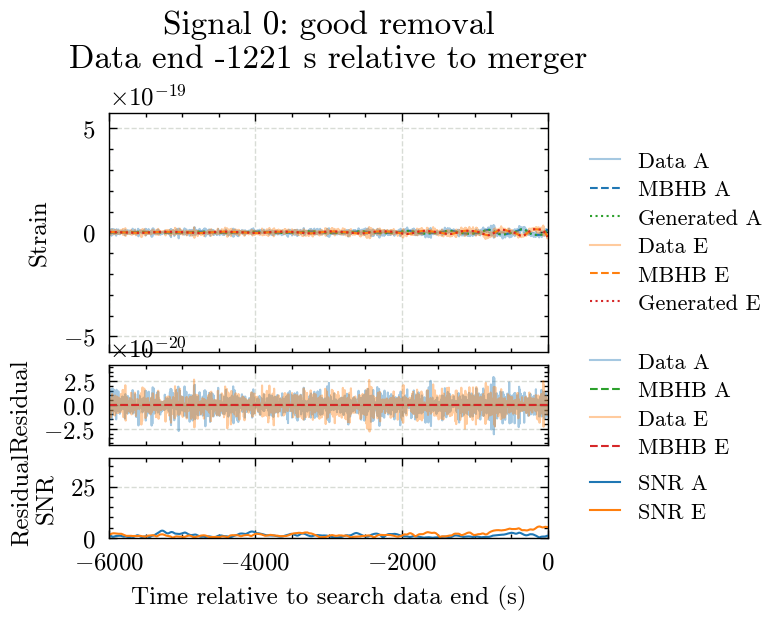

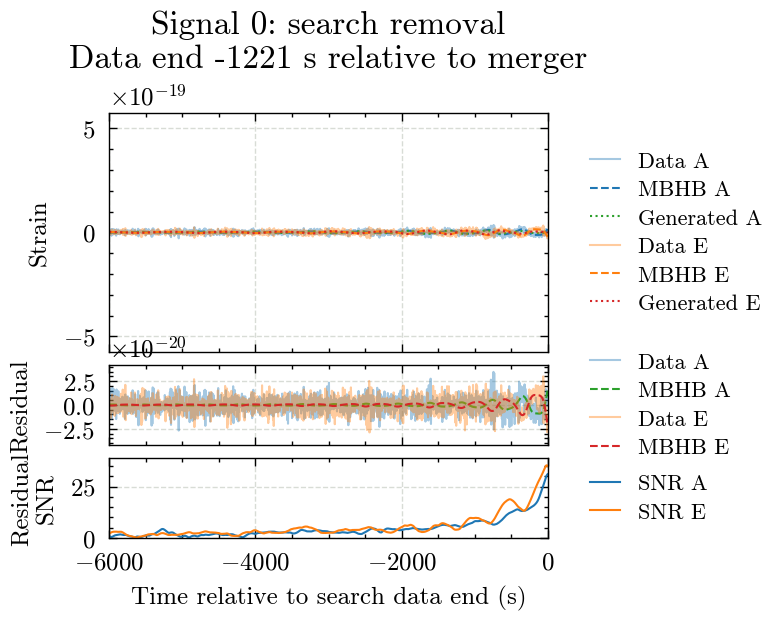

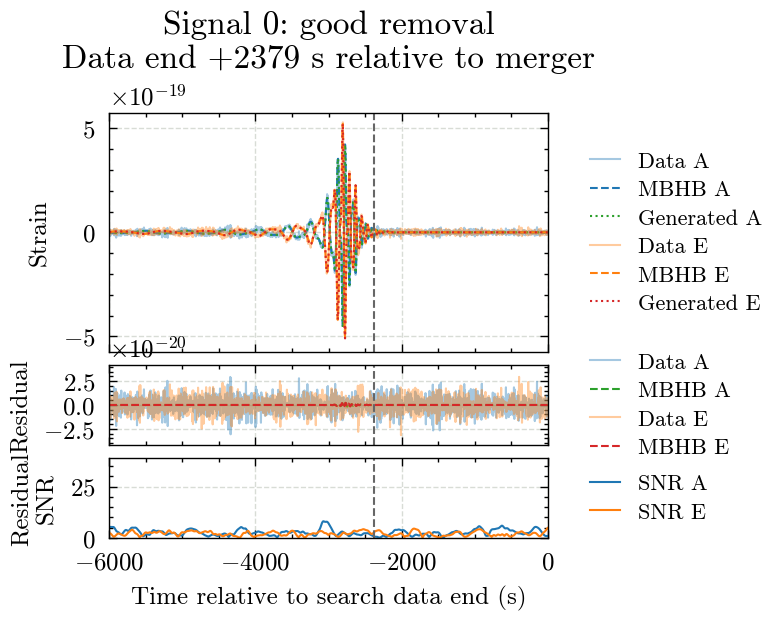

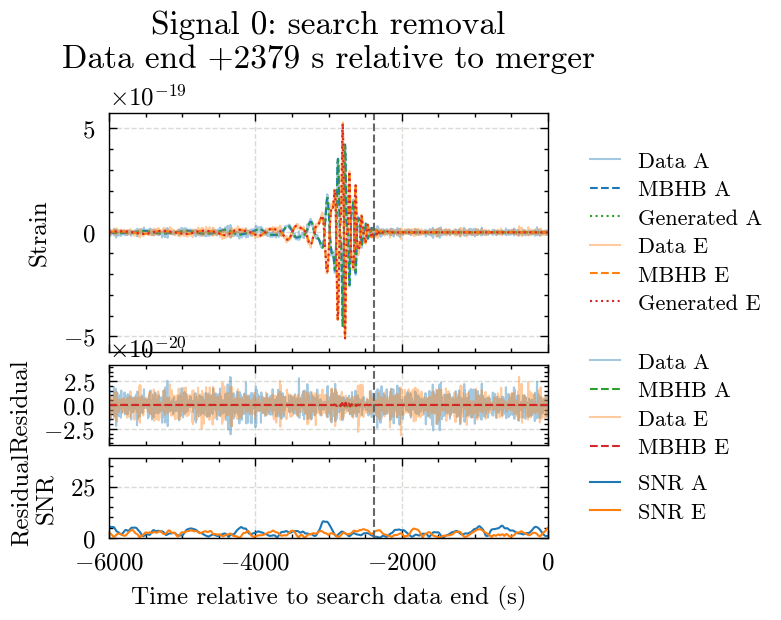

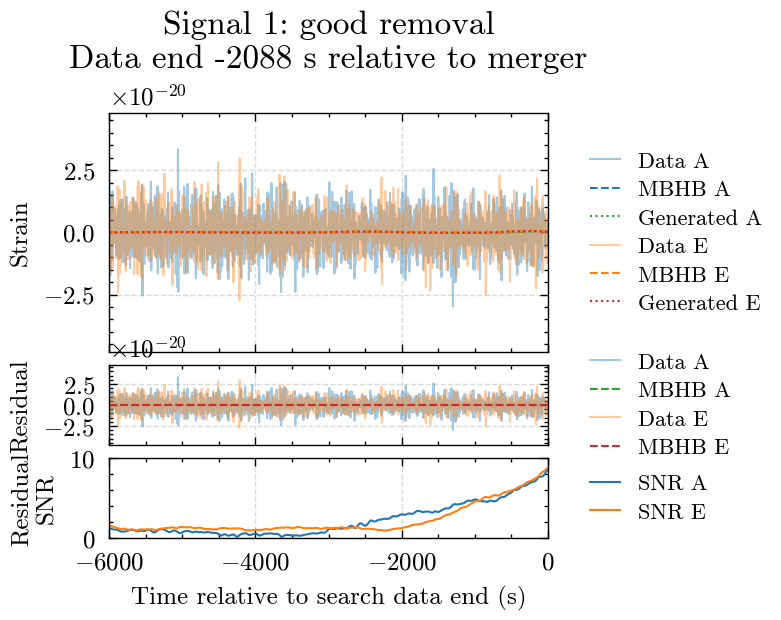

...

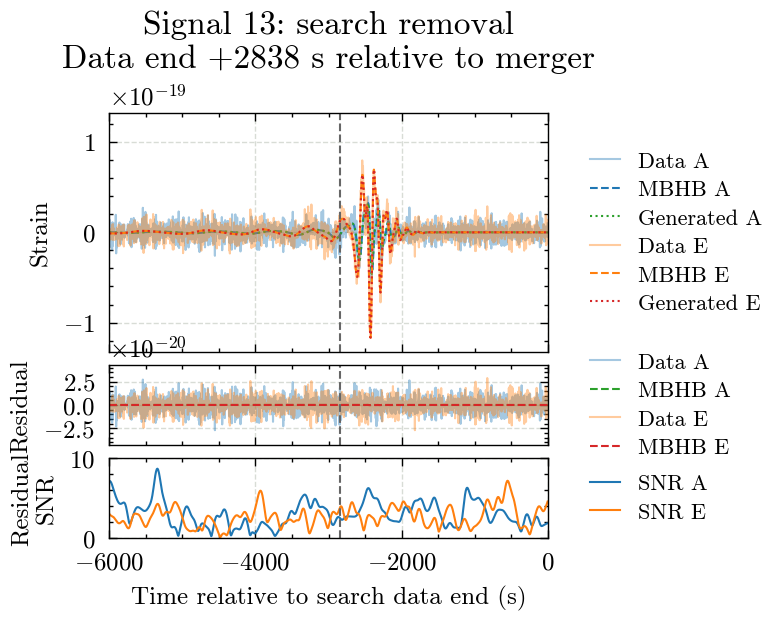

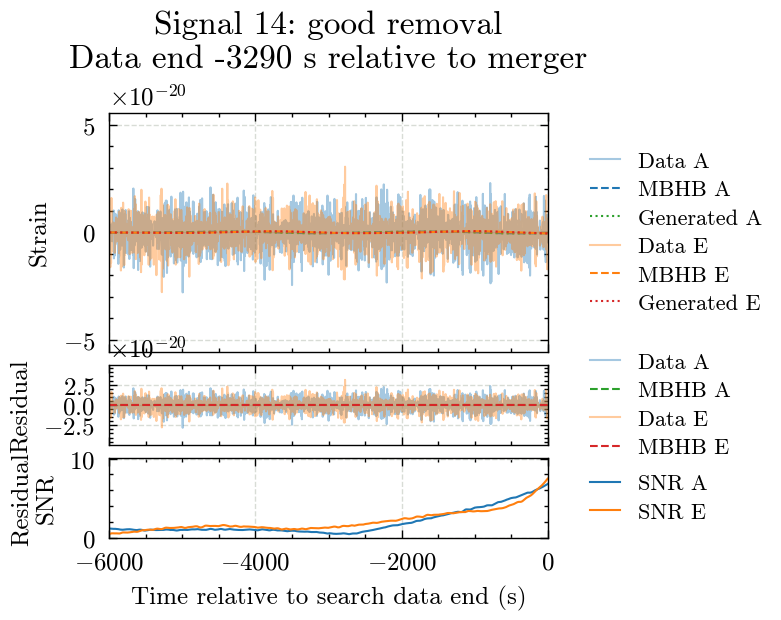

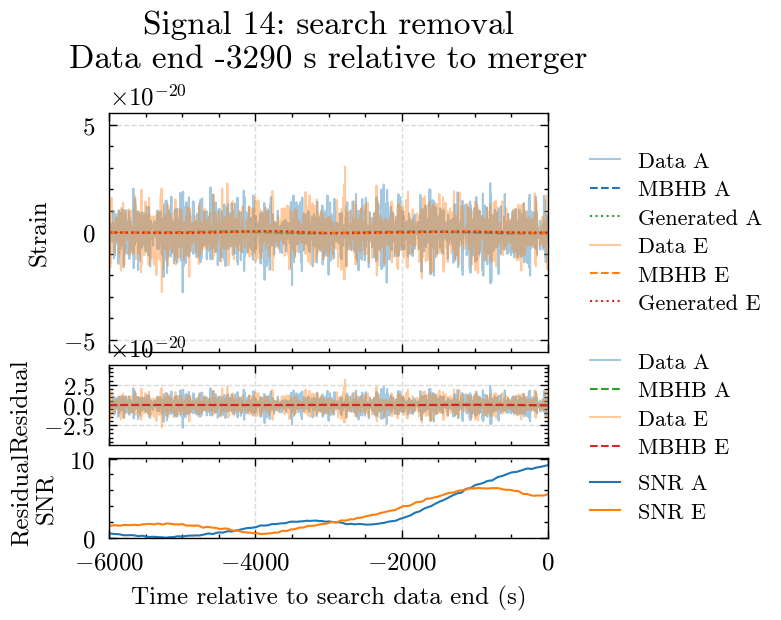

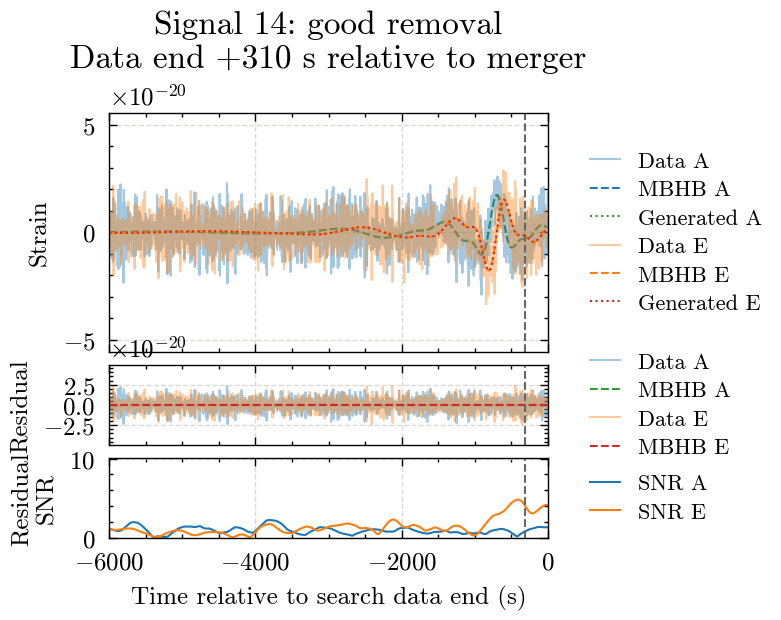

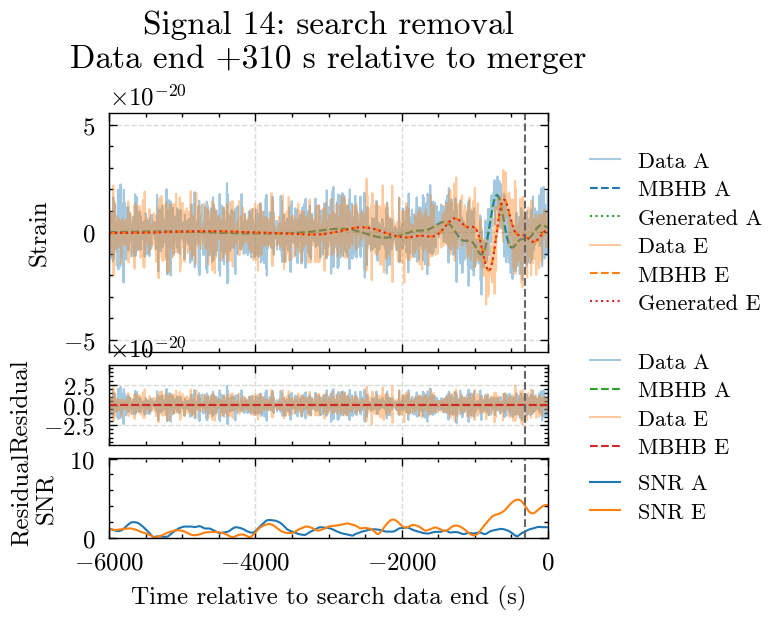

In [9]:
from IPython.display import display

def plot_removal_pairs(signal_number):
    figures = {}
    tc = float(mbhb_sky[signal_number]['CoalescenceTime'])
    for step, version in removal_versions[signal_number].items():
        # Use the data end as the plot reference without changing the catalogue.
        plot_reference = mbhb_sky[signal_number].copy()
        plot_reference['CoalescenceTime'] = version['end']
        for method in ['good', 'bad']:
            fig = plotting_utils.plot_residual_snr(
                signal_number, plot_reference, version['data'], version['mbhb_data'],
                version[f'{method}_residual'], version[f'{method}_mbhb_residual'],
                version['snrs'][method], version[f'{method}_wf'],
                plot_bounds=comparison_bounds,
            )
            method_label = 'good removal' if method == 'good' else 'search removal'
            fig.axes[0].set_title(
                f'Signal {signal_number}: {method_label}\n'
                f'Data end {version["end"] - tc:+.0f} s relative to merger'
            )
            fig.axes[-1].set_xlabel('Time relative to search data end (s)')
            merger_relative = tc - version['end']
            if comparison_bounds[0] <= merger_relative <= comparison_bounds[1]:
                for ax in fig.axes:
                    ax.axvline(merger_relative, color='0.4', linestyle='--')
            figures[(step, method)] = fig

    # Keep all four plots comparable, including the before/after residual amplitudes.
    for panel in [0, 1]:
        limits = [fig.axes[panel].get_ylim() for fig in figures.values()]
        for fig in figures.values():
            ax = fig.axes[panel]
            ax.set_ylim(min(lo for lo, hi in limits), max(hi for lo, hi in limits))
            # Restore automatic scientific notation after changing the shared scale.
            for offset_label in list(ax.texts):
                offset_label.remove()
            ax.yaxis.get_offset_text().set_visible(True)
    snr_max = max(values.max() for version in removal_versions[signal_number].values()
                  for method in ['good', 'bad']
                  for values in version['snrs'][method][signal_number].values())
    for fig in figures.values():
        fig.axes[2].set_ylim(0, max(10, 1.1 * snr_max))
    return figures

for signal_number in comparison_signals:
    comparison_figures = plot_removal_pairs(signal_number)
    for fig in comparison_figures.values():
        display(fig)
        plt.close(fig)
